# 5. Diagnóstico de detección de ciclos ultradianos

Aplica la heurística **detectar_ciclos_rem** (definida abajo, la misma que usa el notebook 6 para construir las matrices por ciclo) sobre la cohorte unificada, **sin generar matrices todavía**.

Objetivo: decidir si conviene calcular matrices por ciclo en los 127 pacientes o restringirlo a un subconjunto con cobertura suficiente.

**Reporta:**
1. Número de ciclos detectados por paciente.
2. Distribución por dataset (CAP, EDF, SCO).
3. Pacientes sin REM (descartados por la heurística).
4. Duración media del ciclo por dataset.
5. Hasta qué ciclo N hay cobertura suficiente (≥ 50% de pacientes).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path("..").resolve()
RUTA_CSV = RAIZ / "dataset/epocas_unificado.csv"
OUT_FIG = RAIZ / "estadisticas"
OUT_FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RUTA_CSV)
print(f"Pacientes: {df['paciente'].nunique()} | Épocas: {len(df)}")
df.head()

Pacientes: 127 | Épocas: 112809


,dataset,paciente,epoca,tiempo,fase_texto,fase_num
0,CAP,CAP_S01_N1,1,22:09:33,Vigilia,0
1,CAP,CAP_S01_N1,2,22:10:03,Vigilia,0
2,CAP,CAP_S01_N1,3,22:10:33,Vigilia,0
3,CAP,CAP_S01_N1,4,22:11:03,Vigilia,0
4,CAP,CAP_S01_N1,5,22:11:33,Vigilia,0


In [2]:
def detectar_ciclos_rem(secuencia, fase_rem=4, umbral_separacion_rem_min=20, epocas_por_minuto=2):
    """Segmenta la noche en ciclos ultradianos a partir de los periodos de REM:
    agrupa épocas REM separadas por menos de 20 min y cierra un ciclo al final de cada periodo.
    fase_rem=4 en la cohorte unificada (0=Vigilia, 1=S1, 2=S2, 3=SWS, 4=REM, 5=Sin clasificar)."""
    indices_rem = [i for i, x in enumerate(secuencia) if x == fase_rem]
    if not indices_rem:
        return []
    periodos_rem = []
    inicio_actual = indices_rem[0]
    fin_actual = indices_rem[0]
    for i in range(1, len(indices_rem)):
        distancia = indices_rem[i] - indices_rem[i-1]
        if distancia <= (umbral_separacion_rem_min * epocas_por_minuto):
            fin_actual = indices_rem[i]
        else:
            periodos_rem.append((inicio_actual, fin_actual))
            inicio_actual = indices_rem[i]
            fin_actual = indices_rem[i]
    periodos_rem.append((inicio_actual, fin_actual))
    ciclos = []
    inicio_ciclo = 0
    for p_inicio, p_fin in periodos_rem:
        ciclos.append((inicio_ciclo, p_fin))
        inicio_ciclo = p_fin + 1
    if inicio_ciclo < len(secuencia):
        ciclos.append((inicio_ciclo, len(secuencia) - 1))
    return ciclos

print("Heurística cargada.")

Heurística cargada.


In [3]:
filas = []
for (ds, pac), g in df.groupby(["dataset", "paciente"], sort=False):
    seq = g.sort_values("epoca")["fase_num"].tolist()
    ciclos = detectar_ciclos_rem(seq, fase_rem=4)
    n_rem = sum(1 for x in seq if x == 4)
    n_epocas = len(seq)
    n_ciclos = len(ciclos)
    if ciclos:
        duraciones = [(fin - ini + 1) / 2 for (ini, fin) in ciclos]  # minutos
        dur_media = float(np.mean(duraciones))
    else:
        dur_media = np.nan
    filas.append(dict(dataset=ds, paciente=pac, n_epocas=n_epocas,
                     n_rem_epocas=n_rem, n_ciclos=n_ciclos, duracion_ciclo_min_media=dur_media))

diag = pd.DataFrame(filas)
diag.to_csv(OUT_FIG / "diagnostico_ciclos_por_paciente.csv", index=False)
print(diag.head())
print(f"\nTotal pacientes: {len(diag)}")

  dataset    paciente  n_epocas  n_rem_epocas  n_ciclos  \
0     CAP  CAP_S01_N1      1140           239         6   
1     CAP  CAP_S02_N1       999           151         5   
2     CAP  CAP_S03_N1       999           188         4   
3     CAP  CAP_S04_N1       979           198         5   
4     CAP  CAP_S05_N1      1007           232         6   

   duracion_ciclo_min_media  
0                 95.000000  
1                 99.900000  
2                124.875000  
3                 97.900000  
4                 83.916667  

Total pacientes: 127


In [4]:
# Resumen por dataset
resumen = (diag.groupby("dataset")
              .agg(pacientes=('paciente','count'),
                   sin_ciclos=('n_ciclos', lambda x: int((x==0).sum())),
                   media_ciclos=('n_ciclos','mean'),
                   mediana_ciclos=('n_ciclos','median'),
                   min_ciclos=('n_ciclos','min'),
                   max_ciclos=('n_ciclos','max'),
                   dur_ciclo_min=('duracion_ciclo_min_media','mean'))
              .round(2))
print(resumen)
resumen.to_csv(OUT_FIG / "diagnostico_ciclos_resumen.csv")

         pacientes  sin_ciclos  media_ciclos  mediana_ciclos  min_ciclos  \
dataset                                                                    
CAP             16           0          5.44             5.5           4   
EDF             82           0          4.43             4.0           2   
SCO             29           0          5.07             5.0           3   

         max_ciclos  dur_ciclo_min  
dataset                             
CAP               6          92.74  
EDF               8         100.68  
SCO               7          92.19  


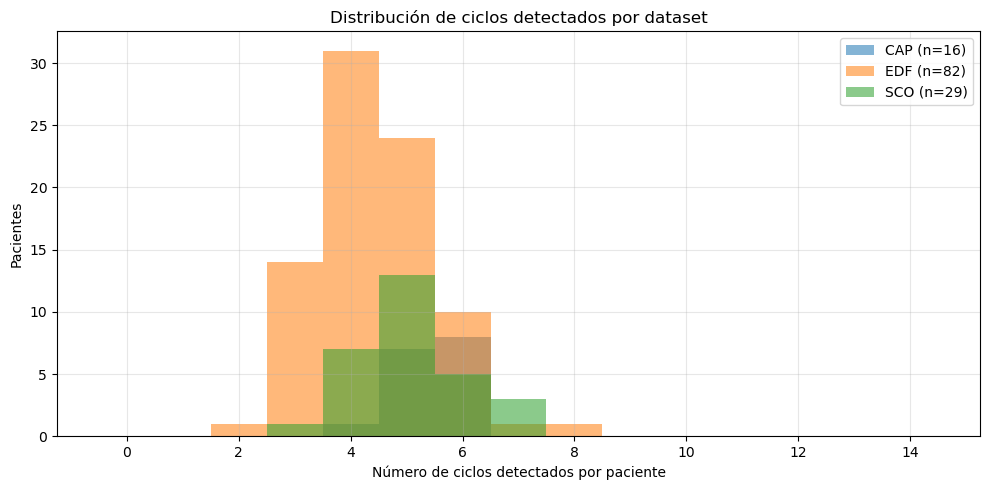

In [5]:
# Distribución de número de ciclos
fig, ax = plt.subplots(figsize=(10, 5))
for ds, g in diag.groupby("dataset"):
    ax.hist(g["n_ciclos"], bins=np.arange(-0.5, 15.5, 1), alpha=0.55, label=f"{ds} (n={len(g)})")
ax.set_xlabel("Número de ciclos detectados por paciente")
ax.set_ylabel("Pacientes")
ax.set_title("Distribución de ciclos detectados por dataset")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG / "diagnostico_ciclos_histograma.png", dpi=300)
plt.show()

In [6]:
# Cobertura: ¿qué fracción de pacientes llega a Ciclo N?
max_c = int(diag["n_ciclos"].max())
cob_rows = []
for n in range(1, max_c + 1):
    for ds, g in diag.groupby("dataset"):
        frac = (g["n_ciclos"] >= n).mean()
        cob_rows.append(dict(dataset=ds, ciclo_N=n, fraccion=round(frac, 3),
                            n_pacientes=int((g["n_ciclos"] >= n).sum())))
    frac_global = (diag["n_ciclos"] >= n).mean()
    cob_rows.append(dict(dataset="TODOS", ciclo_N=n, fraccion=round(frac_global, 3),
                        n_pacientes=int((diag["n_ciclos"] >= n).sum())))
cob = pd.DataFrame(cob_rows)
cob_piv = cob.pivot(index="ciclo_N", columns="dataset", values="fraccion")
print(cob_piv)
cob.to_csv(OUT_FIG / "diagnostico_ciclos_cobertura.csv", index=False)

dataset    CAP    EDF    SCO  TODOS
ciclo_N                            
1        1.000  1.000  1.000  1.000
2        1.000  1.000  1.000  1.000
3        1.000  0.988  1.000  0.992
4        1.000  0.817  0.966  0.874
5        0.938  0.439  0.724  0.567
6        0.500  0.146  0.276  0.220
7        0.000  0.024  0.103  0.039
8        0.000  0.012  0.000  0.008


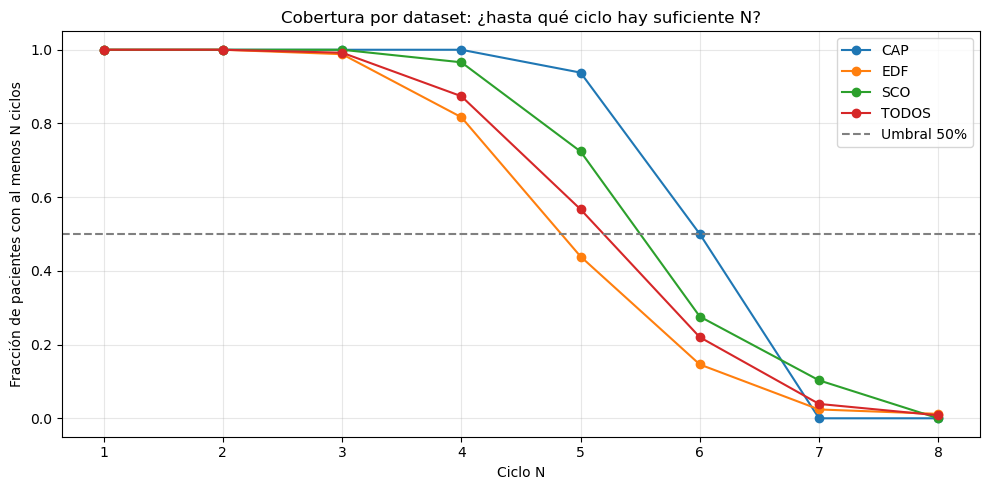

In [7]:
# Visualizar cobertura
fig, ax = plt.subplots(figsize=(10, 5))
for col in cob_piv.columns:
    ax.plot(cob_piv.index, cob_piv[col], marker='o', label=col)
ax.axhline(0.5, color='gray', linestyle='--', label='Umbral 50%')
ax.set_xlabel("Ciclo N")
ax.set_ylabel("Fracción de pacientes con al menos N ciclos")
ax.set_title("Cobertura por dataset: ¿hasta qué ciclo hay suficiente N?")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(range(1, max_c + 1))
plt.tight_layout()
plt.savefig(OUT_FIG / "diagnostico_ciclos_cobertura.png", dpi=300)
plt.show()

In [8]:
# Conclusiones automáticas
print("=" * 60)
print("RESUMEN DIAGNÓSTICO")
print("=" * 60)
print(f"\nTotal pacientes: {len(diag)}")
print(f"Pacientes sin ciclos detectados: {(diag['n_ciclos']==0).sum()}")
print(f"  por dataset: {dict(diag[diag['n_ciclos']==0]['dataset'].value_counts())}")
print(f"\nMedia de ciclos por dataset:")
print(diag.groupby('dataset')['n_ciclos'].mean().round(2).to_string())
print(f"\nÚltimo ciclo con ≥50% de cobertura global:")
last_50 = cob_piv['TODOS'][cob_piv['TODOS'] >= 0.5].index.max()
print(f"  Ciclo {last_50}")
print(f"\nÚltimo ciclo con ≥50% por dataset:")
for col in ['CAP', 'EDF', 'SCO']:
    if col in cob_piv.columns:
        ult = cob_piv[col][cob_piv[col] >= 0.5].index.max()
        print(f"  {col}: Ciclo {ult}")

RESUMEN DIAGNÓSTICO

Total pacientes: 127
Pacientes sin ciclos detectados: 0
  por dataset: {}

Media de ciclos por dataset:
dataset
CAP    5.44
EDF    4.43
SCO    5.07

Último ciclo con ≥50% de cobertura global:
  Ciclo 5

Último ciclo con ≥50% por dataset:
  CAP: Ciclo 6
  EDF: Ciclo 4
  SCO: Ciclo 5
